In [57]:
# 1. Könyvtárak importálása
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # Ez a sor megoldja az "Intel OpenMP" könyvtár duplikációs hibáját, ami néha előfordulhat bizonyos gépeken és könyvtárkombinációknál.

# 2. EZ A KULCS: Környezeti változóként mondjuk meg a Pythonnak, hogy a háttérfolyamatokban is némítsa el ezt a specifikus figyelmeztetést
os.environ["PYTHONWARNINGS"] = "ignore:Found Intel OpenMP:RuntimeWarning"
# Biztonsági öv a fő folyamatnak is
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="threadpoolctl")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, TweedieRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, RobustScaler, StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
import joblib


# 2. Fájlbeolvasás és alap statisztikák
df1 = pd.read_csv('../data/raw/CPU_benchmark_v4.csv')

# print(df1.info())

def get_stats(df, name):
    # Hiányzó értékek (NaN)
    null_counts = df.isnull().sum()
    # Nulla értékek (csak numerikus oszlopoknál releváns)
    zero_counts = (df == 0).sum()

    stats = pd.DataFrame({
        'Hiányzó (NaN)': null_counts,
        'Nulla érték (0)': zero_counts
    })
    print(f"\n--- {name} statisztikák ---")
    print(stats)
    return stats

stats1 = get_stats(df1, "CPU_benchmark_v4")

print(f"Az adathalmaz teljes mérete: {df1.shape[0]} sor és {df1.shape[1]} oszlop")
print(f"Sorok száma hiányzó értékkel: {df1.isnull().any(axis=1).sum()}")
print (f"TDP hiányzik, de Price van: {df1.isnull().any(axis=1).sum() - df1['price'].isna().sum()}")


# 3. GLOBÁLIS ADATTISZTÍTÁS (Csak egyszer fut le!)
def clean_numeric(val):
    if isinstance(val, str):
        return float(val.replace(',', ''))
    return val

# A powerPerf, price, stb. konverziója stringből floattá a teljes df_clean-en
numeric_cols = ['price', 'cpuMark', 'threadMark', 'TDP', 'powerPerf', 'cores']
for col in numeric_cols:
    if col in df1.columns:
        df1[col] = df1[col].apply(clean_numeric)

# 4. GLOBÁLIS VÁLTOZÓK (Socket csoportosítás)
top_20_sockets = df1['socket'].value_counts().nlargest(20).index
df1['socket_grouped'] = df1['socket'].apply(lambda x: x if x in top_20_sockets else 'Other')

df_inference = df1[df1['TDP'].isna() & df1['price'].notna()].copy()
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'CPU_benchmark_v4_inference.csv')
df_inference.to_csv(output_path, index=False)
print(f"Sikeresen elmentve {len(df_inference)} processzor a '{output_path}' fájlba!")

# Ezután már biztonságosan eldobhatjuk a TDP hiányzó értékeket a statisztikákhoz, hogy ne torzítsák az elemzést
df_clean = df1.dropna(subset=['TDP']).copy()
stats2 = get_stats(df_clean, "CPU_benchmark_v4")

# 5. FEATURE LISTÁK
# A) Korrelációs analízishez (itt vizsgálni akarjuk a powerPerf-et is)
corr_features = ['price', 'cpuMark', 'threadMark', 'TDP', 'powerPerf', 'cores', 'testDate', 'category']

# C) Ár (price) modellezéséhez és pótlásához (itt a célváltozók és deriváltak nincsenek bent)
features_price = ['cpuMark', 'threadMark', 'TDP', 'cores', 'testDate', 'category', 'socket_grouped']

# D) Végső Power Performance predikcióhoz (itt az ár már fontos bemeneti változó)
features_pp = ['price', 'threadMark', 'cores', 'testDate', 'category', 'socket_grouped']


--- CPU_benchmark_v4 statisztikák ---
             Hiányzó (NaN)  Nulla érték (0)
cpuName                  0                0
price                 1858                0
cpuMark                  0                0
cpuValue              1858                0
threadMark               0                0
threadValue           1858                0
TDP                    685                0
powerPerf              685                0
cores                    0                0
testDate                 0                0
socket                   0                0
category                 0                0
Az adathalmaz teljes mérete: 3825 sor és 12 oszlop
Sorok száma hiányzó értékkel: 1887
TDP hiányzik, de Price van: 29
Sikeresen elmentve 29 processzor a '../data/processed\CPU_benchmark_v4_inference.csv' fájlba!

--- CPU_benchmark_v4 statisztikák ---
                Hiányzó (NaN)  Nulla érték (0)
cpuName                     0                0
price                    1202                

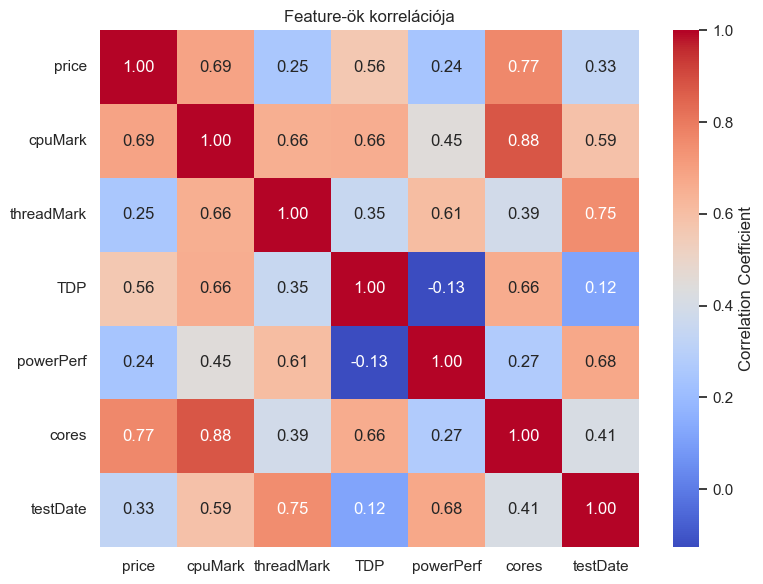

In [58]:
# === Korreláció-analízis ===
# Csak azokat az oszlopokat tartjuk meg, amik ténylegesen benne vannak a df_clean-ben
existing_features = [f for f in corr_features if f in df_clean.columns]
df_analysis_clean = df_clean[existing_features].copy()

# One-Hot Encoding alkalmazása
df_corr_analysis = pd.get_dummies(df_analysis_clean, columns=['category'] if 'category' in df_analysis_clean.columns else [], prefix='cat')

# Csak a numerikus oszlopok kiválasztása
numeric_df = df_corr_analysis.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature-ök korrelációja')
plt.tight_layout()
plt.show()

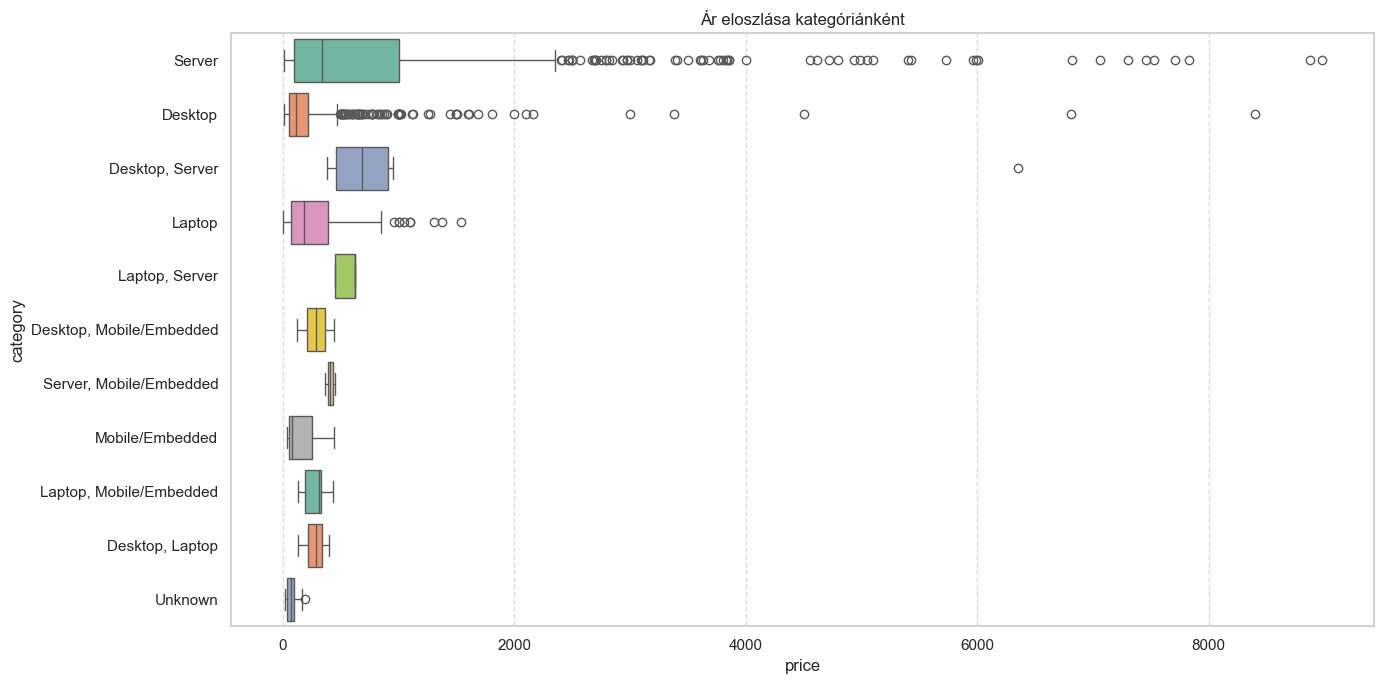

Átlagos árak kategóriánként:


category
Desktop, Server             1577.606667
Server                       876.659148
Laptop, Server               549.791429
Server, Mobile/Embedded      408.500000
Desktop, Mobile/Embedded     284.500000
Laptop, Mobile/Embedded      277.205556
Desktop, Laptop              274.497500
Laptop                       247.489302
Desktop                      224.677866
Mobile/Embedded              151.933333
Unknown                       73.625000
Name: price, dtype: float64

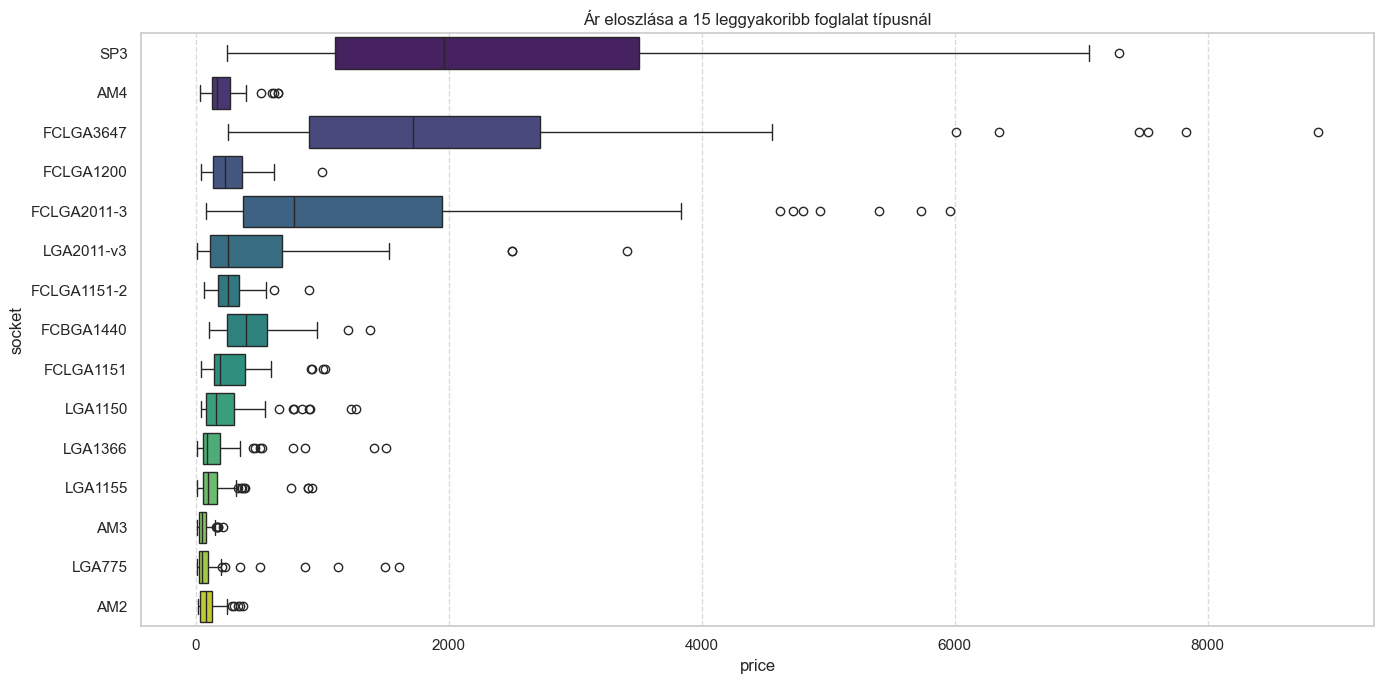

Átlagos árak a leggyakoribb socket-eknél:


socket
SP3            2467.452000
FCLGA3647      2187.002763
FCLGA2011-3    1569.967778
LGA2011-v3      595.902500
FCBGA1440       436.907308
FCLGA1151       293.376667
FCLGA1151-2     282.030349
LGA1150         266.194167
FCLGA1200       263.642688
AM4             219.615385
LGA1366         198.111167
LGA1155         153.730426
LGA775          135.242716
AM2             102.816444
AM3              60.246111
Name: price, dtype: float64

In [59]:
# Csak azokat a sorokat nézzük, ahol van ár
df_price_analysis = df_clean.dropna(subset=['price']).copy()

# 1. Ár eloszlása Category szerint
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_price_analysis, x='price', y='category', hue='category', palette='Set2', legend=False)
plt.title('Ár eloszlása kategóriánként')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Átlagos árak kategóriánként:")
display(df_price_analysis.groupby('category')['price'].mean().sort_values(ascending=False))

# 2. Ár eloszlása a leggyakoribb Socket-ek szerint (Top 15)
top_sockets = df_price_analysis['socket'].value_counts().nlargest(15).index
df_top_sockets_price = df_price_analysis[df_price_analysis['socket'].isin(top_sockets)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top_sockets_price, x='price', y='socket', hue='socket', palette='viridis', legend=False)
plt.title('Ár eloszlása a 15 leggyakoribb foglalat típusnál')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Átlagos árak a leggyakoribb socket-eknél:")
display(df_top_sockets_price.groupby('socket')['price'].mean().sort_values(ascending=False))

In [60]:
# Új könyvtárak importálása (ezeket a notebook elejéhez is teheted)


# === Finding best Price regression ===
# Adatok előkészítése: itt a df_clean már a tisztított formátumú
df_price_base = df_clean.dropna(subset=['price'] + features_price).copy()
print(df_price_base.info())
results_list_price = []

# --- 1. Modell eredmények (eredeti adatokon + Socket) ---
y_orig_price = df_price_base["price"]
X_orig_price = pd.get_dummies(df_price_base[features_price], columns=["category", "socket_grouped"])
X_train_orig_price, X_test_orig_price, y_train_orig_price, y_test_orig_price = train_test_split(X_orig_price, y_orig_price, test_size=0.2, random_state=42)

# Kibővített modell lista (XGBoost, CatBoost és egy RobustScaler-el ellátott SVR)
models_orig_price = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "RandomForest_Original": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost_Original": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42),
    "CatBoost_Original": CatBoostRegressor(iterations=200, learning_rate=0.05, depth=6, random_seed=42, verbose=0),
    "SVR_Robust_Original": make_pipeline(RobustScaler(), SVR(kernel='rbf', C=100.0, gamma='scale')),
    "HistGradientBoosting_Original": HistGradientBoostingRegressor(loss='poisson', random_state=42),
    "PolinomialRidge_original": make_pipeline(PolynomialFeatures(degree=2), StandardScaler(), Ridge(alpha=10.0)),
    "TweedieRegression_Original": make_pipeline(StandardScaler(), TweedieRegressor(power=1.5, link='log')),
    "KNN_Original": make_pipeline(RobustScaler(), KNeighborsRegressor(n_neighbors=5)),
}

print("--- Modell eredmények (eredeti adatokon - Price) ---")
for name, model in models_orig_price.items():
    model.fit(X_train_orig_price, y_train_orig_price)
    y_pred = model.predict(X_test_orig_price)
    rmse = np.sqrt(mean_squared_error(y_test_orig_price, y_pred))
    mae = mean_absolute_error(y_test_orig_price, y_pred)
    r2 = r2_score(y_test_orig_price, y_pred)
    results_list_price.append({'Modell': f"{name}", 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})

# --- 2. Modell eredmények (logaritmikus transzformációval + Socket) ---
y_orig_log_price = np.log1p(y_orig_price)
X_train_orig_log_price, X_test_orig_log_price, y_train_orig_log_price, y_test_orig_log_price = train_test_split(X_orig_price, y_orig_log_price, test_size=0.2, random_state=42)

# Ugyanezek a modellek bevetése a logaritmizált célváltozón is
models_log_orig_price = {
    "Linear_LogTransformed": LinearRegression(),
    "Ridge_LogTransformed": Ridge(alpha=10.0),
    "Lasso_LogTransformed": Lasso(alpha=0.1),
    "ElasticNet_LogTransformed": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "RandomForest_LogTransformed": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost_LogTransformed": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42),
    "CatBoost_LogTransformed": CatBoostRegressor(iterations=200, learning_rate=0.05, depth=6, random_seed=42, verbose=0),
    "SVR_Robust_LogTransformed": make_pipeline(RobustScaler(), SVR(kernel='rbf', C=10.0, gamma='scale')),
    "HistGradientBoosting_LogTransformed": HistGradientBoostingRegressor(loss='poisson', random_state=42),
    "PolinomialRidge_LogTransformed": make_pipeline(PolynomialFeatures(degree=2), StandardScaler(), Ridge(alpha=10.0)),
}

print("\n--- Modell eredmények (log transzformáció - Price) ---")
for name, model in models_log_orig_price.items():
    model.fit(X_train_orig_log_price, y_train_orig_log_price)
    y_pred_log = model.predict(X_test_orig_log_price)
    y_pred = np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_test_orig_price, y_pred))
    mae = mean_absolute_error(y_test_orig_price, y_pred)
    r2 = r2_score(y_test_orig_price, y_pred)
    results_list_price.append({'Modell': f"{name}", 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})

# --- 3. Modell eredmények (outlierek kezelése IQR-rel) ---
Q1_price = df_price_base['price'].quantile(0.25)
Q3_price = df_price_base['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

df_filtered_price = df_price_base[(df_price_base['price'] >= lower_bound_price) & (df_price_base['price'] <= upper_bound_price)].copy()

y_filt_price = df_filtered_price["price"]
X_filt_price = pd.get_dummies(df_filtered_price[features_price], columns=["category", "socket_grouped"])
X_train_filt_price, X_test_filt_price, y_train_filt_price, y_test_filt_price = train_test_split(X_filt_price, y_filt_price, test_size=0.2, random_state=42)

models_filtered_price = {
    "Linear_IQR": LinearRegression(),
    "RandomForest_IQR": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost_IQR": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
}

print("\n--- Modell eredmények (outlierek kezelése IQR-rel - Price) ---")
for name, model in models_filtered_price.items():
    model.fit(X_train_filt_price, y_train_filt_price)
    y_pred_filt = model.predict(X_test_filt_price)
    rmse_filt = np.sqrt(mean_squared_error(y_test_filt_price, y_pred_filt))
    mae_filt = mean_absolute_error(y_test_filt_price, y_pred_filt)
    r2_filt = r2_score(y_test_filt_price, y_pred_filt)
    results_list_price.append({'Modell': f"{name}", 'RMSE': rmse_filt, 'MAE': mae_filt, 'R2 Score': r2_filt})

# Eredmények összegzése
comparison_df_price = pd.DataFrame(results_list_price).sort_values(by="R2 Score", ascending=False)
display(comparison_df_price)

<class 'pandas.DataFrame'>
Index: 1938 entries, 1 to 3747
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cpuName         1938 non-null   str    
 1   price           1938 non-null   float64
 2   cpuMark         1938 non-null   int64  
 3   cpuValue        1938 non-null   float64
 4   threadMark      1938 non-null   int64  
 5   threadValue     1938 non-null   float64
 6   TDP             1938 non-null   float64
 7   powerPerf       1938 non-null   float64
 8   cores           1938 non-null   int64  
 9   testDate        1938 non-null   int64  
 10  socket          1938 non-null   str    
 11  category        1938 non-null   str    
 12  socket_grouped  1938 non-null   str    
dtypes: float64(5), int64(4), str(4)
memory usage: 300.7 KB
None
--- Modell eredmények (eredeti adatokon - Price) ---

--- Modell eredmények (log transzformáció - Price) ---

--- Modell eredmények (outlierek kezelése IQR-rel - Price) 

,Modell,RMSE,MAE,R2 Score
24,XGBoost_IQR,117.145572,79.482182,0.620447
23,RandomForest_IQR,119.342221,80.809237,0.606080
9,PolinomialRidge_original,509.627774,224.352901,0.568388
21,PolinomialRidge_LogTransformed,517.677321,203.247788,0.554646
3,ElasticNet,529.129353,259.153176,0.534723
1,Ridge,536.806687,261.407296,0.521124
16,RandomForest_LogTransformed,537.418863,197.198897,0.520031
18,CatBoost_LogTransformed,538.034487,197.885886,0.518931
19,SVR_Robust_LogTransformed,538.593768,201.164576,0.517930
10,TweedieRegression_Original,539.387057,236.298924,0.516509


In [61]:
# === 2. LÉPCSŐ: Price Predikciós Modell ===

# 1. TANÍTÁS: Szigorúan az eredeti, valós Price-szal ÉS valós TDP-vel rendelkező adatokon!
# Itt df_clean-et használunk, NEM a df_cascade-et!
df_price_train = df_clean.dropna(subset=['price'] + features_price).copy()

# Logaritmizáljuk az árat!
y_price_train_log = np.log1p(df_price_train['price'])
X_price_train = pd.get_dummies(df_price_train[features_price], columns=['category', 'socket_grouped'])

# Price Modell betanítása a tiszta adatokon
price_model = RandomForestRegressor(n_estimators=100, random_state=42)
price_model.fit(X_price_train, y_price_train_log)


df_cascade = df_clean.copy()
# 2. PÓTLÁS (Imputation): Ahol az eredeti adatbázisban (df_cascade) hiányzott az ár.
missing_price_mask = df_cascade['price'].isnull()
df_missing_price = df_cascade[missing_price_mask].copy()

if not df_missing_price.empty:
    X_missing_price = pd.get_dummies(df_missing_price[features_price], columns=['category', 'socket_grouped'])
    X_missing_price = X_missing_price.reindex(columns=X_price_train.columns, fill_value=0)
    
    # Becsült Árak beírása a cascade adatbázisba
    df_cascade.loc[missing_price_mask, 'price'] = np.round(np.expm1(price_model.predict(X_missing_price)), 2)
    df_cascade['price_is_imputed'] = missing_price_mask.astype(int)

# Opcionális: Származtatott értékek (cpuValue, threadValue) újraszámolása a már teli adatbázisban
df_cascade['cpuValue'] = df_cascade['cpuMark'] / df_cascade['price']
df_cascade['threadValue'] = df_cascade['threadMark'] / df_cascade['price']

print(f"2. LÉPCSŐ KÉSZ: Hiányzó Price értékek pótolva {missing_price_mask.sum()} sorban.")

df_cascade.to_csv('../data/processed/CPU_benchmark_v4_price_imputed.csv', index=False)
print('Kiegészített adathalmaz elmentve!')

2. LÉPCSŐ KÉSZ: Hiányzó Price értékek pótolva 1202 sorban.
Kiegészített adathalmaz elmentve!


In [62]:
# === Finding best Power Performance regression ===
from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor

# Adatok előkészítése: A már imputált (árral kiegészített) adatbázist használjuk
# Csak azokat a sorokat nézzük, ahol a powerPerf NEM hiányzik (ez a gold standard tanítóhalmaz)



df_pp_base = df_cascade.dropna(subset=['powerPerf'] + features_pp).copy()
print(df_pp_base.info())
results_list_pp = []

# Itt a features_pp globális listát használjuk (amiben benne van a pótolt price is!)
y_orig_pp = df_pp_base["powerPerf"]
X_orig_pp = pd.get_dummies(df_pp_base[features_pp], columns=["category", "socket_grouped"])

# --- 1. Modell eredmények (eredeti adatokon) ---
X_train_orig_pp, X_test_orig_pp, y_train_orig_pp, y_test_orig_pp = train_test_split(X_orig_pp, y_orig_pp, test_size=0.2, random_state=42)

base_estimators1 = [
    ('xgb', XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42)),
    ('hgb', HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42)),
    # más logika: KNN és SVR ( RobustScalerrel)
    ('knn', make_pipeline(RobustScaler(), KNeighborsRegressor(n_neighbors=10))),
    ('svr', make_pipeline(RobustScaler(), SVR(kernel='rbf', C=100.0, gamma='scale')))
]
base_estimators2 = [
    ('xgb', XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42)),
    ('hgb', HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42)),
    
    # RF helyett egy teljesen más logika: KNN (a RobustScaler kötelező elé!)
    ('knn', make_pipeline(RobustScaler(), KNeighborsRegressor(n_neighbors=10))),
    
    ('xgb_log', TransformedTargetRegressor(
        regressor=XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42),
        func=np.log1p, 
        inverse_func=np.expm1
    )),
]
def stacking_model(base_estimators):
    return StackingRegressor(
        estimators=base_estimators,
        final_estimator=ElasticNet(alpha=0.05, l1_ratio=0.5), # Meta-modell csere Lasso-ra, hogy kiszűrje a gyenge prediktorokat
        cv=5,
        n_jobs=-1, # Hogy mindegyik CPU magot használja, gyorsabb legyen a futás
        passthrough=True # A meta-modell látja az eredeti oszlopokat is
    )

def stacking_model2(base_estimators):
    return StackingRegressor(
        estimators=base_estimators,
        final_estimator=RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42), # Meta-modell csere RF-re, hogy komplexebb mintázatokat is megtanuljon
        cv=5,
        n_jobs=-1,
        passthrough=True
    )

models_orig_pp = {
    "Linear": make_pipeline(RobustScaler(), LinearRegression()),
    "Ridge": make_pipeline(RobustScaler(), Ridge(alpha=10.0)),
    "Lasso": make_pipeline(RobustScaler(), Lasso(alpha=0.5)),
    "ElasticNet": make_pipeline(RobustScaler(), ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=2000)),
    "RandomForest_Original": RandomForestRegressor(n_estimators=100, max_depth=7, min_samples_leaf=5, random_state=42),
    "XGBoost_Original": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42),
    "CatBoost_Original": CatBoostRegressor(iterations=200, learning_rate=0.05, depth=6, l2_leaf_reg=5.0, random_seed=42, verbose=0),
    "SVR_Robust_Original": make_pipeline(RobustScaler(), SVR(kernel='rbf', C=10.0, gamma='scale')),
    "HistGradientBoosting_Original": HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42),
    "PolinomialRidge_original": make_pipeline(RobustScaler(), PolynomialFeatures(degree=2), Ridge(alpha=50.0)),
    "TweedieRegression_Original": make_pipeline(RobustScaler(), TweedieRegressor(power=1.5, link='log')),
    "KNN_Robust_Original": make_pipeline(RobustScaler(), KNeighborsRegressor(n_neighbors=10)),
    "Stacking_Original": stacking_model(base_estimators1),
    "Stacking2_Original": stacking_model(base_estimators2),
    "Stacking3_Original": stacking_model2(base_estimators1),
    "Stacking4_Original": stacking_model2(base_estimators2),
    "MLP_NeuralNet_Original": make_pipeline(RobustScaler(), MLPRegressor(hidden_layer_sizes=(64, 32), alpha=0.1, validation_fraction=0.1, max_iter=500, early_stopping=True, random_state=42))
}

print("--- Modell eredmények (eredeti adatokon - PowerPerf) ---")
for name, model in models_orig_pp.items():
    model.fit(X_train_orig_pp, y_train_orig_pp)
    y_pred = model.predict(X_test_orig_pp)
    rmse = np.sqrt(mean_squared_error(y_test_orig_pp, y_pred))
    mae = mean_absolute_error(y_test_orig_pp, y_pred)
    r2 = r2_score(y_test_orig_pp, y_pred)
    results_list_pp.append({'Modell': f"{name}", 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})

# --- 2. Modell eredmények (logaritmikus transzformációval) ---
# Biztonságos logaritmus (log1p), ha lennének 0 közeli értékek
y_orig_log_pp = np.log1p(y_orig_pp)
X_train_orig_log_pp, X_test_orig_log_pp, y_train_orig_log_pp, y_test_orig_log_pp = train_test_split(X_orig_pp, y_orig_log_pp, test_size=0.2, random_state=42)

models_log_orig_pp = {
    "Linear_log": make_pipeline(RobustScaler(), LinearRegression()),
    "Ridge_log": make_pipeline(RobustScaler(), Ridge(alpha=10.0)),
    "Lasso_log": make_pipeline(RobustScaler(), Lasso(alpha=0.5)),
    "ElasticNet_log": make_pipeline(RobustScaler(), ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=2000)),
    "RandomForest_log": RandomForestRegressor(n_estimators=100, max_depth=7, min_samples_leaf=5, random_state=42),
    "XGBoost_log": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42),
    "CatBoost_log": CatBoostRegressor(iterations=200, learning_rate=0.05, depth=6, l2_leaf_reg=5.0, random_seed=42, verbose=0),
    "SVR_Robust_log": make_pipeline(RobustScaler(), SVR(kernel='rbf', C=10.0, gamma='scale')),
    "HistGradientBoosting_log": HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42),
    "PolinomialRidge_log": make_pipeline(RobustScaler(), PolynomialFeatures(degree=2), Ridge(alpha=50.0)),
    "KNN_Robust_log": make_pipeline(RobustScaler(), KNeighborsRegressor(n_neighbors=10)),
    "Stacking_log": stacking_model(base_estimators1),
    "Stacking2_log": stacking_model(base_estimators2),
    "Stacking3_log": stacking_model2(base_estimators1),
    "Stacking4_log": stacking_model2(base_estimators2),
    "MLP_NeuralNet_log": make_pipeline(RobustScaler(), MLPRegressor(hidden_layer_sizes=(64, 32), alpha=0.1, validation_fraction=0.1, max_iter=500, early_stopping=True, random_state=42))
}

print("\n--- Modell eredmények (log transzformáció - PowerPerf) ---")
for name, model in models_log_orig_pp.items():
    model.fit(X_train_orig_log_pp, y_train_orig_log_pp)
    y_pred_log = model.predict(X_test_orig_log_pp)
    y_pred = np.expm1(y_pred_log) # Visszaalakítás a valós skálára
    rmse = np.sqrt(mean_squared_error(y_test_orig_pp, y_pred))
    mae = mean_absolute_error(y_test_orig_pp, y_pred)
    r2 = r2_score(y_test_orig_pp, y_pred)
    results_list_pp.append({'Modell': f"{name}", 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})

# --- Eredmények összefoglalása ---
comparison_df_pp = pd.DataFrame(results_list_pp).sort_values(by="R2 Score", ascending=False)
display(comparison_df_pp)

<class 'pandas.DataFrame'>
Index: 3140 entries, 0 to 3824
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cpuName           3140 non-null   str    
 1   price             3140 non-null   float64
 2   cpuMark           3140 non-null   int64  
 3   cpuValue          3140 non-null   float64
 4   threadMark        3140 non-null   int64  
 5   threadValue       3140 non-null   float64
 6   TDP               3140 non-null   float64
 7   powerPerf         3140 non-null   float64
 8   cores             3140 non-null   int64  
 9   testDate          3140 non-null   int64  
 10  socket            3140 non-null   str    
 11  category          3140 non-null   str    
 12  socket_grouped    3140 non-null   str    
 13  price_is_imputed  3140 non-null   int64  
dtypes: float64(5), int64(5), str(4)
memory usage: 508.0 KB
None
--- Modell eredmények (eredeti adatokon - PowerPerf) ---

--- Modell eredmények (log transzf

,Modell,RMSE,MAE,R2 Score
8,HistGradientBoosting_Original,76.184206,36.763537,0.783439
12,Stacking_Original,76.235042,35.908606,0.783150
13,Stacking2_Original,76.760783,35.843052,0.780149
5,XGBoost_Original,76.864695,36.022681,0.779553
14,Stacking3_Original,79.032138,37.668118,0.766945
25,HistGradientBoosting_log,79.547492,36.805879,0.763896
16,MLP_NeuralNet_Original,79.565661,40.109226,0.763788
22,XGBoost_log,79.724844,35.060267,0.762842
15,Stacking4_Original,79.845012,37.693337,0.762126
6,CatBoost_Original,80.030669,38.988713,0.761019


Valós árak száma a tanítóhalmazban: 1202 sor
Modell: XGBoost, RMSE: 76.86469511656068, MAE: 36.02268135095098, R2 Score: 0.7795529350334607
Modell: HistGradientBoosting, RMSE: 76.18420635426817, MAE: 36.763536769229475, R2 Score: 0.7834389250232711


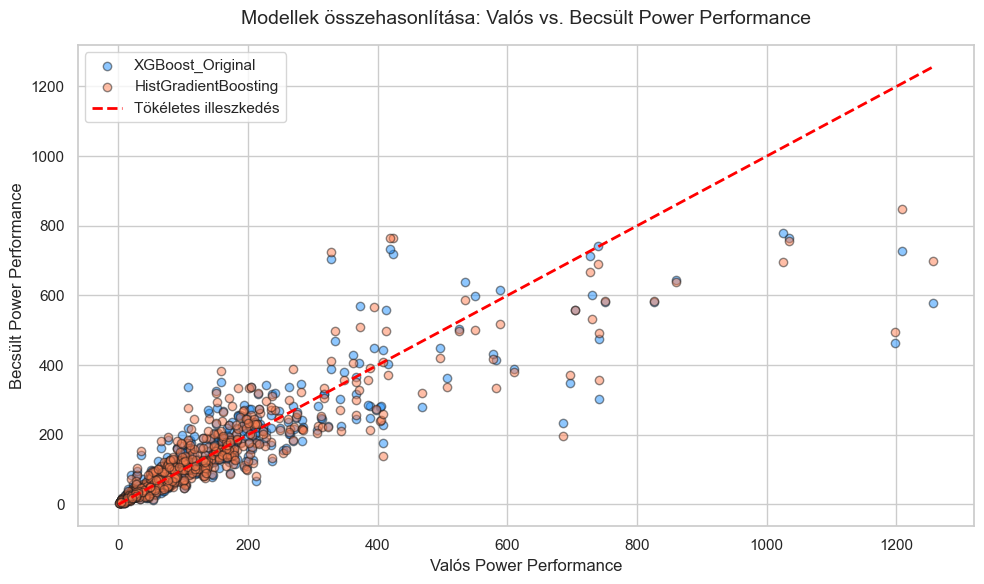

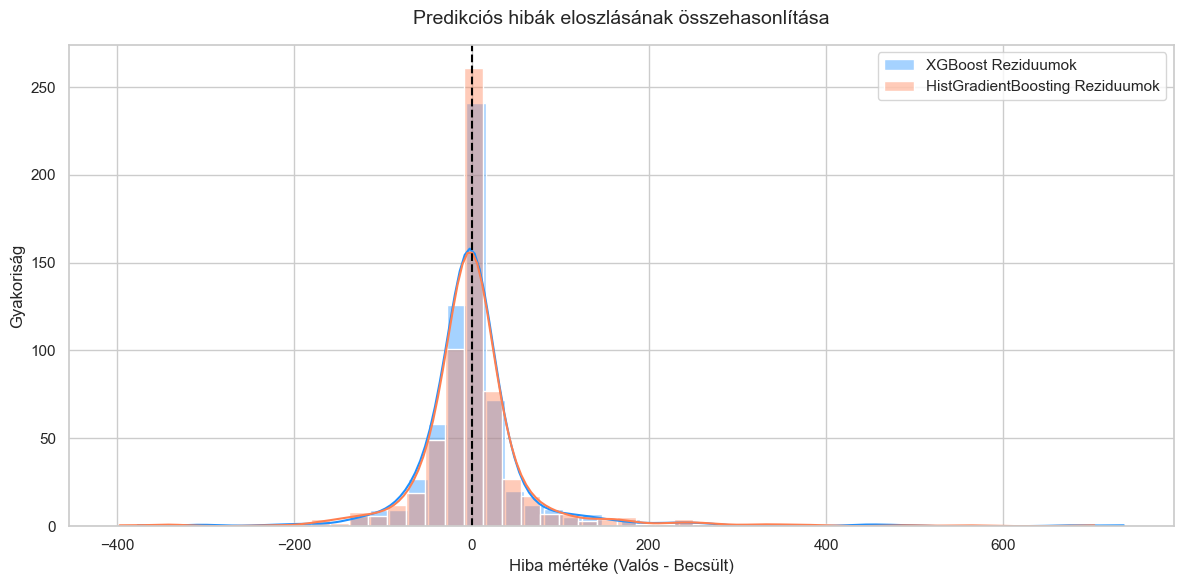

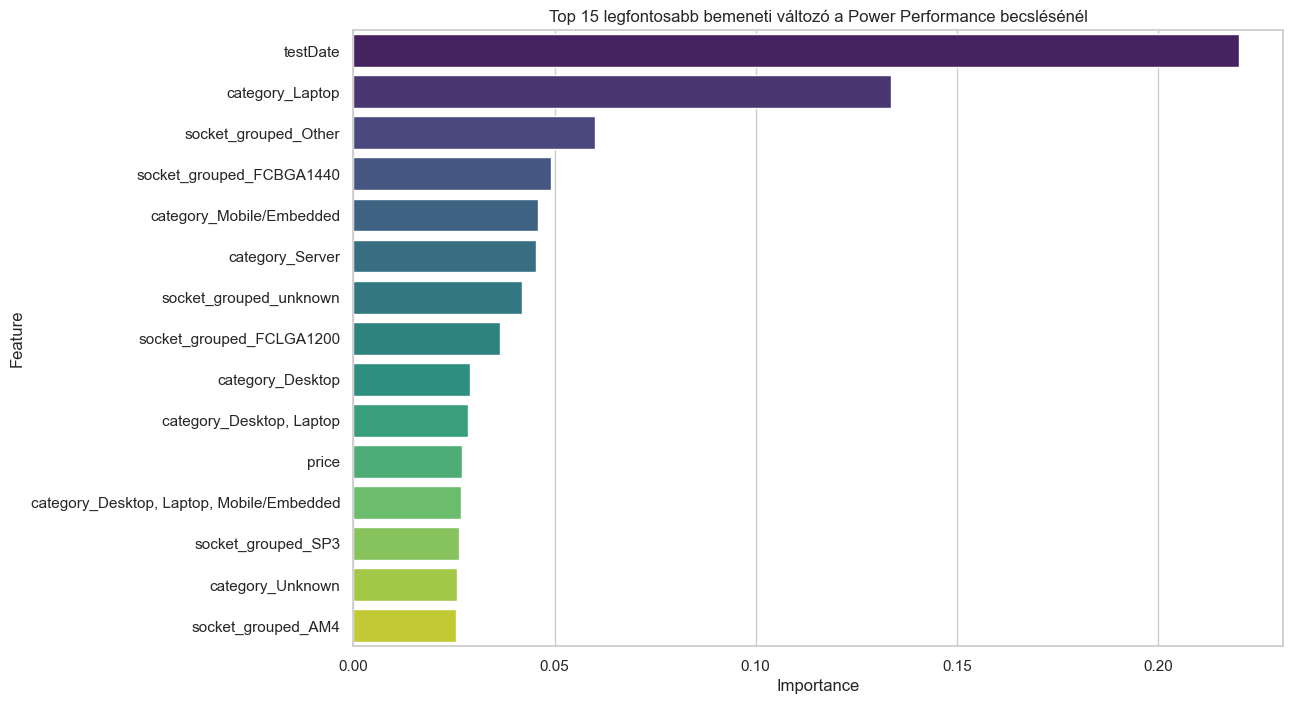

In [63]:
# === TELJESÍTMÉNY ANALÍZIS ÉS VIZUALIZÁCIÓ ===

# Predikció a logaritmikus teszthalmazon
df_pp_train = df_cascade.dropna(subset=['powerPerf'] + features_pp).copy()

y_pp_eval = df_pp_train['powerPerf']
X_pp_eval = pd.get_dummies(df_pp_train[features_pp], columns=['category', 'socket_grouped'])

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_pp_eval, y_pp_eval, test_size=0.2, random_state=42
)

pp_model1 = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.8, random_state=42)
pp_model2 = HistGradientBoostingRegressor(loss='poisson', max_depth=5, l2_regularization=2.0, random_state=42)
pp_model1.fit(X_train_v, y_train_v)
pp_model2.fit(X_train_v, y_train_v)

y_pred_xgb = pp_model1.predict(X_test_v)
y_pred_hgb = pp_model2.predict(X_test_v)
valami = 0
for price_is_imputed in df_pp_train['price_is_imputed']:
    if price_is_imputed == 1:
        valami += 1
print (f"Valós árak száma a tanítóhalmazban: {valami} sor")

rmse = np.sqrt(mean_squared_error(y_test_orig_pp, y_pred_xgb))
mae = mean_absolute_error(y_test_orig_pp, y_pred_xgb)
r2 = r2_score(y_test_orig_pp, y_pred_xgb)
print(f"Modell: XGBoost, RMSE: {rmse}, MAE: {mae}, R2 Score: {r2}")

rmse_hgb = np.sqrt(mean_squared_error(y_test_orig_pp, y_pred_hgb))
mae_hgb = mean_absolute_error(y_test_orig_pp, y_pred_hgb)
r2_hgb = r2_score(y_test_orig_pp, y_pred_hgb)   
print(f"Modell: HistGradientBoosting, RMSE: {rmse_hgb}, MAE: {mae_hgb}, R2 Score: {r2_hgb}")



sns.set_theme(style="whitegrid")

# --- A) Valós vs. Becsült értékek ---
plt.figure(figsize=(10, 6))
# XGBoost pontok (Dodgerblue, enyhén átlátszó)
plt.scatter(y_test_v, y_pred_xgb, alpha=0.5, color='dodgerblue', edgecolor='k', label='XGBoost_Original')
# HistGradientBoosting pontok (Coral színnel, hogy jól elkülönüljön)
plt.scatter(y_test_v, y_pred_hgb, alpha=0.5, color='coral', edgecolor='k', label='HistGradientBoosting')
# Tökéletes illeszkedés vonala
max_val = max(y_test_v.max(), y_pred_xgb.max(), y_pred_hgb.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Tökéletes illeszkedés')
plt.title('Modellek összehasonlítása: Valós vs. Becsült Power Performance', fontsize=14, pad=15)
plt.xlabel('Valós Power Performance', fontsize=12)
plt.ylabel('Becsült Power Performance', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# --- B) Hibák (Reziduumok) eloszlása ---
residuals_xgb = y_test_v - y_pred_xgb
residuals_hgb = y_test_v - y_pred_hgb
plt.figure(figsize=(12, 6))
# XGBoost hiba eloszlás
sns.histplot(residuals_xgb, kde=True, color='dodgerblue', alpha=0.4, label='XGBoost Reziduumok')
# Stacking hiba eloszlás
sns.histplot(residuals_hgb, kde=True, color='coral', alpha=0.4, label='HistGradientBoosting Reziduumok')
# 0 hiba vonala
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Predikciós hibák eloszlásának összehasonlítása', fontsize=14, pad=15)
plt.xlabel('Hiba mértéke (Valós - Becsült)', fontsize=12)
plt.ylabel('Gyakoriság', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# --- C) Feature Importance (Top 15) ---
importance = pd.DataFrame({
    'Feature': X_pp_eval.columns,
    'Importance': pp_model1.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance.head(15), x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 legfontosabb bemeneti változó a Power Performance becslésénél')
plt.show()

In [64]:
# === 3. LÉPCSŐ: Power Performance Predikciós Modell (Fő feladat) ===

# 1. TANÍTÁS: Valós PowerPerf és Valós Price megléte esetén (Eredeti df_cascade-ből származtatva)
# (A df_cascade-ben ha van powerPerf, akkor van TDP is)
df_pp_train = df_cascade.dropna(subset=['powerPerf'] + features_pp).copy()

# Logaritmizáljuk a hatékonyságot!
y_pp_train = df_pp_train['powerPerf']
X_pp_train = pd.get_dummies(df_pp_train[features_pp], columns=['category', 'socket_grouped'])

pp_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
pp_model.fit(X_pp_train, y_pp_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [65]:
# === Betanított modell és oszlopstruktúra mentése a webapphoz ===

# Mappa létrehozása, ha még nem létezne
os.makedirs('../models', exist_ok=True)

# 2. Price (Ár) modell és oszlopok mentése
joblib.dump(price_model, '../models/price_model.pkl')
joblib.dump(list(X_price_train.columns), '../models/price_model_columns.pkl')

# 3. Power Performance modell és oszlopok mentése
joblib.dump(pp_model, '../models/powerPerf_model.pkl')
joblib.dump(list(X_pp_eval.columns), '../models/powerPerf_model_columns.pkl')

# Mentsük ki a kategóriákat és a top socketeket is, amiket a modell ismer
joblib.dump(list(df_cascade['category'].unique()), '../models/categories_list.pkl')
# Fontos, hogy az 'Other' is benne legyen a listában a webapp számára
top_sockets_with_other = list(top_20_sockets)
if 'Other' not in top_sockets_with_other:
    top_sockets_with_other.append('Other')
joblib.dump(top_sockets_with_other, '../models/sockets_list.pkl')

print("Minden modell (Price, PowerPerf) és oszlopstruktúra sikeresen elmentve a ../models mappába!")

Minden modell (Price, PowerPerf) és oszlopstruktúra sikeresen elmentve a ../models mappába!
